# EDA — Mushroom Edibility Classification Dataset

## Цель EDA

Exploratory Data Analysis (EDA) проводится для:

- анализа структуры датасета;
- проверки качества данных;
- анализа train / validation / test выборок;
- проверки дисбаланса классов;
- анализа распределения изображений;
- подготовки данных для ML-пайплайна.

Используемый датасет:

**Edible & Poisonous Mushroom Classification**  
Источник: Kaggle  
https://www.kaggle.com/datasets/benedictusjason/edible-and-poisonous-mushroom-classification


# Структура датасета

После скачивания датасет имеет следующую структуру:

```text
data/raw/splitted_dataset/
├── train/
│   ├── edible/
│   └── poisonous/
├── val/
│   ├── edible/
│   └── poisonous/
└── test/
    ├── edible/
    └── poisonous/
```

Датасет уже разделён на:
- train;
- validation;
- test.

Поэтому дополнительный split выполнять не требуется.


In [1]:
import os
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import seaborn as sns


# Загрузка путей к изображениям

In [2]:
DATA_DIR = Path("../data/raw/splitted_dataset")

splits = ["train", "val", "test"]
classes = ["edible", "poisonous"]

data = []

for split in splits:
    for class_name in classes:

        class_dir = DATA_DIR / split / class_name

        if class_dir.exists():
            for img_name in os.listdir(class_dir):

                data.append({
                    "image_path": class_dir / img_name,
                    "label": class_name,
                    "split": split
                })

eda_df = pd.DataFrame(data)

eda_df.head()


,image_path,label,split
0,..\data\raw\splitted_dataset\train\edible\Agar...,edible,train
1,..\data\raw\splitted_dataset\train\edible\Agar...,edible,train
2,..\data\raw\splitted_dataset\train\edible\Agar...,edible,train
3,..\data\raw\splitted_dataset\train\edible\Agar...,edible,train
4,..\data\raw\splitted_dataset\train\edible\Agar...,edible,train


# Размер датасета

In [3]:
print(f"Общее количество изображений: {len(eda_df)}")

eda_df.groupby(["split", "label"]).size()


Общее количество изображений: 2820


split  label    
test   edible        150
       poisonous     132
train  edible       1200
       poisonous    1056
val    edible        150
       poisonous     132
dtype: int64

# Распределение данных по выборкам

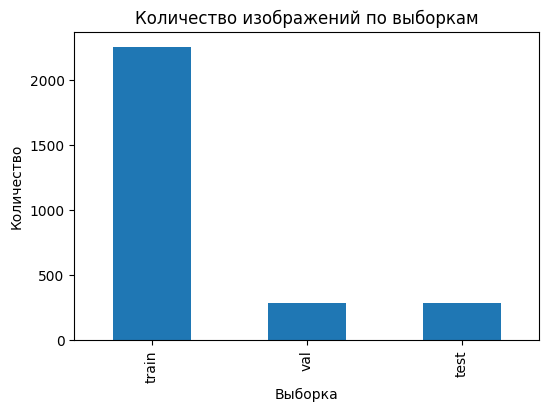

In [4]:
split_counts = eda_df["split"].value_counts()

plt.figure(figsize=(6,4))
split_counts.plot(kind="bar")

plt.title("Количество изображений по выборкам")
plt.xlabel("Выборка")
plt.ylabel("Количество")

plt.show()


# Распределение классов

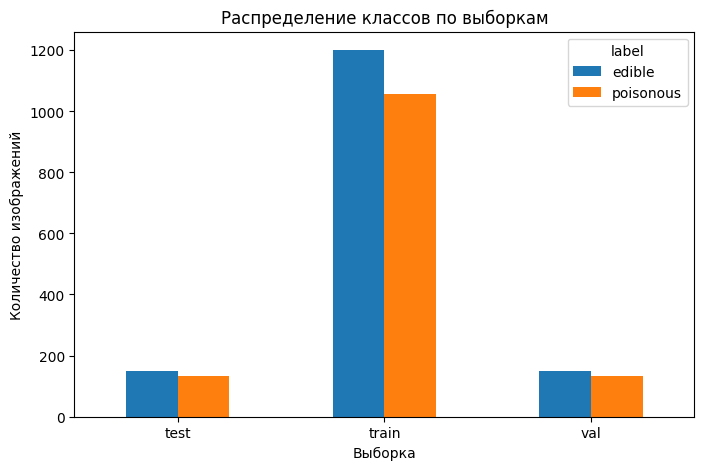

In [5]:
class_counts = eda_df.groupby(["split", "label"]).size().unstack()

class_counts.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Распределение классов по выборкам")
plt.xlabel("Выборка")
plt.ylabel("Количество изображений")

plt.xticks(rotation=0)
plt.show()


## Вывод

Необходимо проверить наличие дисбаланса классов.

Если дисбаланс существенный, будут использоваться:
- augmentation;
- weighted loss;
- stratified sampling.


# Проверка форматов изображений

In [6]:
formats = []

for path in eda_df["image_path"]:

    try:
        with Image.open(path) as img:
            formats.append(img.format)

    except:
        formats.append("CORRUPTED")

Counter(formats)


Counter({'JPEG': 2647, 'PNG': 159, 'MPO': 8, 'WEBP': 6})

## Цель проверки

Проверяем:
- наличие битых изображений;
- единообразие форматов;
- возможность чтения файлов.


# Проверка размеров изображений

In [7]:
widths = []
heights = []

for path in eda_df["image_path"]:

    try:
        with Image.open(path) as img:
            widths.append(img.size[0])
            heights.append(img.size[1])

    except:
        pass

print(f"Средняя ширина: {np.mean(widths):.2f}")
print(f"Средняя высота: {np.mean(heights):.2f}")


Средняя ширина: 1044.97
Средняя высота: 869.14


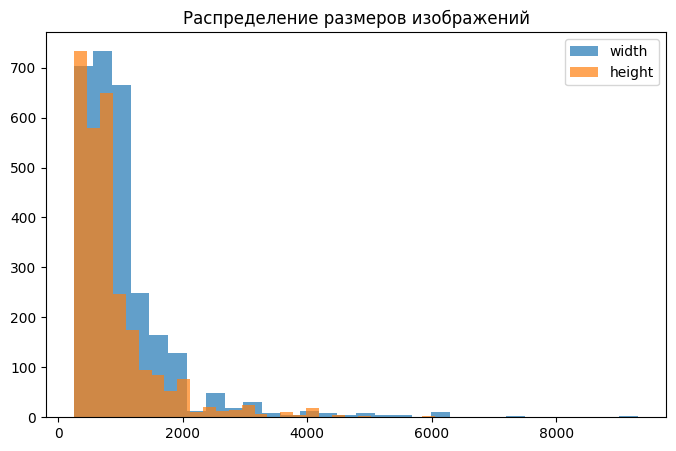

In [8]:
plt.figure(figsize=(8,5))

plt.hist(widths, bins=30, alpha=0.7, label="width")
plt.hist(heights, bins=30, alpha=0.7, label="height")

plt.legend()

plt.title("Распределение размеров изображений")

plt.show()


## Вывод

Изображения имеют разные размеры, поэтому перед обучением модели будет использоваться:

```python
Resize((224, 224))
```


# Визуальный просмотр изображений

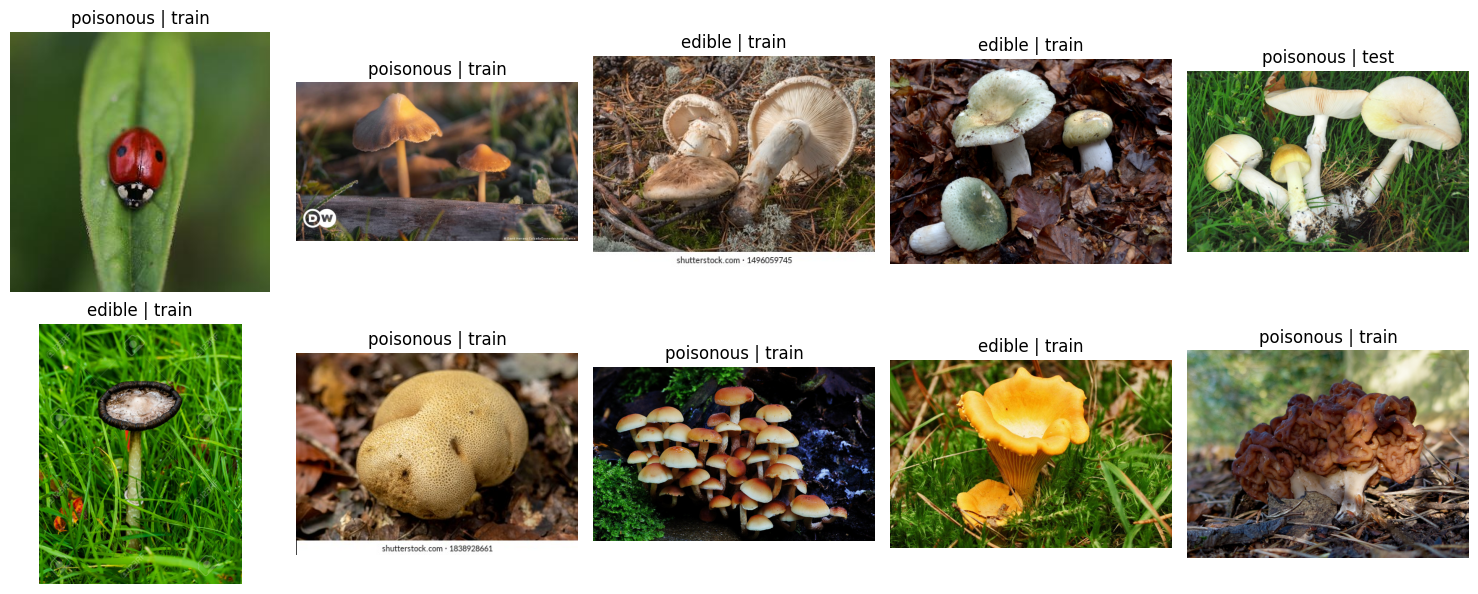

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

sample_df = eda_df.sample(min(10, len(eda_df)))

for ax, (_, row) in zip(axes.flatten(), sample_df.iterrows()):

    img = Image.open(row["image_path"])

    ax.imshow(img)
    ax.set_title(f"{row['label']} | {row['split']}")
    ax.axis("off")

plt.tight_layout()
plt.show()


## Цель

Визуальная проверка позволяет:
- обнаружить шум;
- проверить качество изображений;
- выявить артефакты;
- оценить вариативность фона и освещения.


# Проверка битых изображений

In [10]:
broken_images = []

for path in eda_df["image_path"]:

    try:
        img = Image.open(path)
        img.verify()

    except:
        broken_images.append(path)

print(f"Количество битых изображений: {len(broken_images)}")


Количество битых изображений: 0


## Вывод

Битые изображения должны быть удалены до обучения модели.


# Планируемый preprocessing

In [11]:
from torchvision import transforms

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

preprocess


Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

# Планируемая augmentation

In [12]:
augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    )
])

augmentation


Compose(
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
)

## Зачем нужна augmentation

Позволяет:
- уменьшить overfitting;
- повысить устойчивость модели;
- улучшить качество на новых изображениях.


# Основные выводы EDA

## Выводы

1. Датасет уже разделён на train / validation / test.

2. Изображения имеют разные размеры, поэтому требуется preprocessing.

3. Необходимо удалить битые изображения.

4. Возможен дисбаланс классов.

5. Для baseline-модели планируется использовать:
- ResNet18;
- EfficientNet-B0.

6. Размер входного изображения:
```text
224 x 224
```

7. Основные метрики:
- Accuracy;
- Precision;
- Recall;
- F1-score;
- ROC-AUC.

Особый приоритет:
- Recall для класса poisonous.
